# Imputation, denoising, generation, and perturbation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/generation.ipynb)

A trained UniVI model is a generative model: its decoders map any latent point to every modality. This notebook uses that to

- **denoise** measured expression, from one modality or several
- **evaluate cross-modal prediction** feature by feature
- **generate** new cells, unconditionally or for a chosen cell type, in all modalities at once
- **probe** the model with an in-silico perturbation of one input feature

RNA is kept as log-normalized expression without z-scoring here, so that zero means "not expressed" and decoded values are on a familiar scale.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.0"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch

import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import (denoise_adata, encode_adata, evaluate_cross_reconstruction,
                              fit_label_latent_gaussians, generate_from_latent, sample_latent_by_label)
from univi.perturbation import predict_feature_perturbation
from univi.plotting import compare_raw_vs_denoised_umap_features, plot_featurewise_reconstruction_scatter
from univi.preprocessing import ATACPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)
dense = lambda x: x.toarray() if sp.issparse(x) else np.asarray(x)

C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 400
BATCH_SIZE = 256
N_HVG = 2000
N_LSI = 101
N_GENERATED = 2000

## Train

In [4]:
data = uds.pbmc_multiome_10k()
rna, atac = data["rna"], data["atac"]
splits = split_by_label(rna.obs["cell_type"], train_fraction=0.8, val_fraction=0.1, seed=0)
rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=False).fit(rna[splits["train"]])   # log1p, not z-scored
atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=True, scale=True).fit(atac[splits["train"]])
parts = {k: {"rna": rna_prep.transform(rna[i]), "atac": atac_prep.transform(atac[i])} for k, i in splits.items()}
train, val, test = parts["train"], parts["val"], parts["test"]

cfg = UniVIConfig(
    latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
    kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
    modalities=[ModalityConfig("rna", train["rna"].n_vars, [512, 256, 128], [128, 256, 512]),
                ModalityConfig("atac", train["atac"].n_vars, [128, 64], [64, 128])],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
UniVITrainer(model, make_loader(train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
             make_loader(val, batch_size=1024),
             TrainingConfig(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4, device=device,
                            early_stopping=True, patience=50, best_epoch_warmup=110, log_every=50)).fit();

rna_test, atac_test = test["rna"], test["atac"]
rna_test.obsm["X_univi"] = encode_adata(model, rna_test, modality="rna", device=device, latent="modality_mean")
sc.pp.neighbors(rna_test, use_rep="X_univi")
sc.tl.umap(rna_test, random_state=0)
markers = [g for g in ["MS4A1", "CD79A", "CD3D", "IL7R", "NKG7", "GNLY", "LYZ", "FCGR3A"] if g in rna_test.var_names]

[2026-09-21 00:58:52,478] [UniVITrainer] [INFO] TrainingConfig:


[2026-09-21 00:58:52,478] [UniVITrainer] [INFO]   n_epochs: 400


[2026-09-21 00:58:52,479] [UniVITrainer] [INFO]   batch_size: 256


[2026-09-21 00:58:52,479] [UniVITrainer] [INFO]   lr: 0.001


[2026-09-21 00:58:52,479] [UniVITrainer] [INFO]   weight_decay: 0.0001


...

Training UniVI:  48%|████▊     | 191/400 [04:54<05:20,  1.53s/it, beta=1.250, gamma=4.350, train_loss=586.0810, val_loss=563.8258]

Training UniVI:  48%|████▊     | 191/400 [04:56<05:20,  1.53s/it, beta=1.250, gamma=4.350, train_loss=586.1165, val_loss=563.3881]

[2026-09-21 01:03:48,690] [UniVITrainer] [INFO] Early stopping at epoch 192 (best val loss=562.1112, best epoch=142)


Training UniVI:  48%|████▊     | 191/400 [04:56<05:24,  1.55s/it, beta=1.250, gamma=4.350, train_loss=586.1165, val_loss=563.3881]


[2026-09-21 01:03:48,723] [UniVITrainer] [INFO] Restored best model from epoch 142 (val loss=562.1112)


## Denoise

`denoise_adata` encodes cells and decodes the same modality into a new layer. With `adata_by_mod`, the encoding uses every modality supplied (the fused posterior), so accessibility also informs the denoised expression.

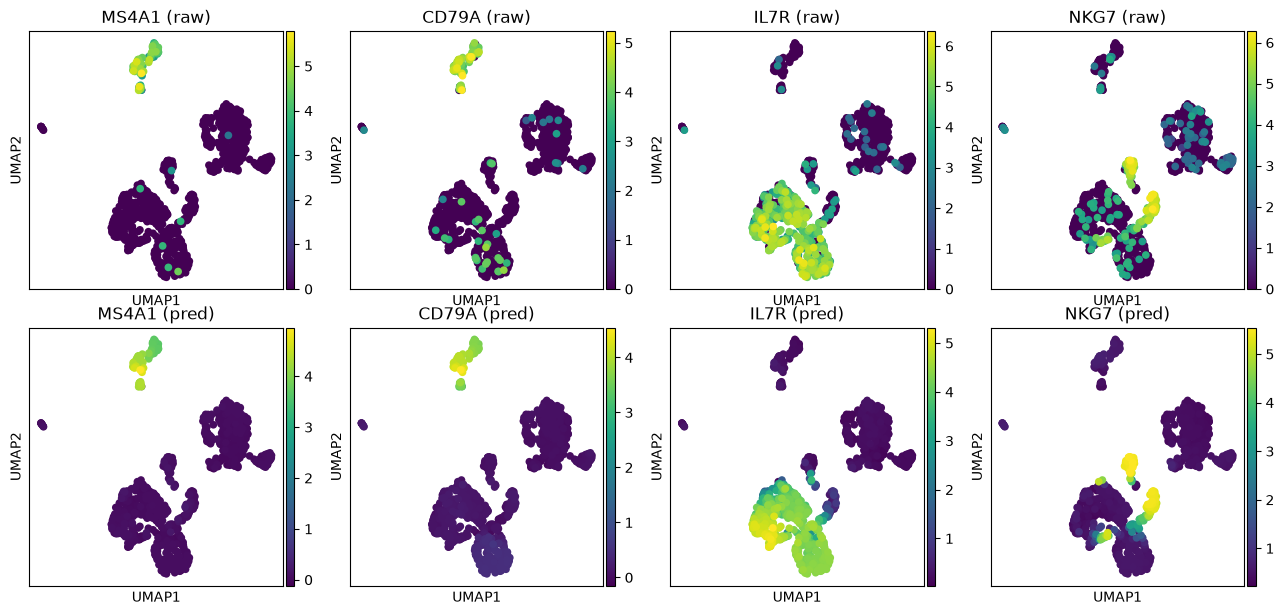

In [5]:
denoise_adata(model, rna_test, modality="rna", device=device, out_layer="denoised_rna_only")
denoise_adata(model, rna_test, modality="rna", device=device, out_layer="denoised_rna_atac", adata_by_mod=test)
compare_raw_vs_denoised_umap_features(rna_test, obsm_key="X_univi", features=markers[:4],
                                      denoised_layer="denoised_rna_atac")

Denoised values are model estimates: good for visualization and for spotting marker patterns, but they are smoother than real biology and should not replace measured counts in differential-expression tests.

## Cross-modal prediction, feature by feature

{'mse_mean': 0.536, 'mse_median': 0.207, 'pearson_mean': 0.301, 'pearson_median': 0.278, 'per_cell_mean': 0.536}


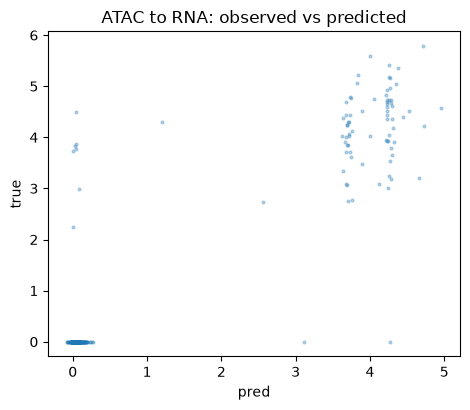

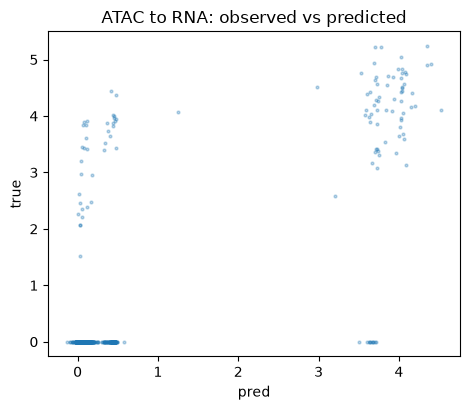

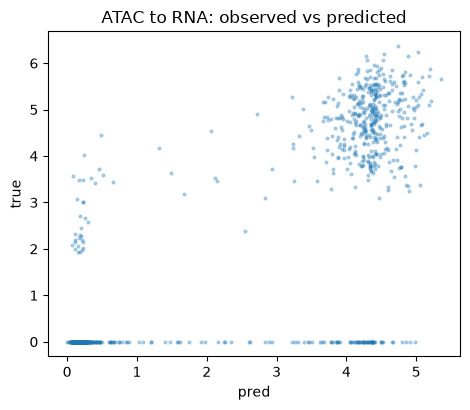

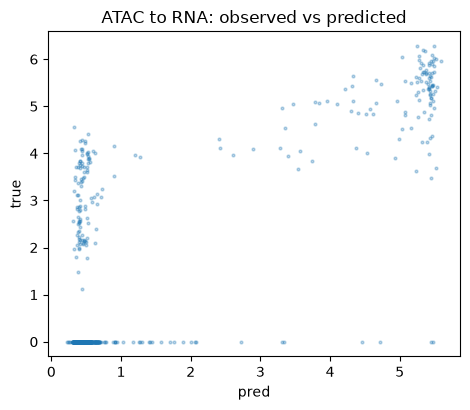

In [6]:
rep = evaluate_cross_reconstruction(model, atac_test, rna_test, src_mod="atac", tgt_mod="rna", device=device)
print({k: round(float(v), 3) for k, v in rep["summary"].items()})
plot_featurewise_reconstruction_scatter(rep, features=markers[:4], title="ATAC to RNA: observed vs predicted")

## Generate cells

### From the prior

Sampling latent points from the standard-normal prior and decoding them produces synthetic cells. With no `target_mod`, every modality is decoded from the same latent points, so the generated RNA and ATAC profiles belong together.

In [7]:
generated = generate_from_latent(model, n=N_GENERATED, device=device, z_source="prior")
{mod: x.shape for mod, x in generated.items()}

{'rna': (2000, 2000), 'atac': (2000, 100)}

A quick check: encode the generated RNA and look at it next to real test cells. Prior samples cover the whole region the model has learned, including the space between cell types, so they are useful for exploring the model but are not a substitute for a specific population. For that, sample per cell type (next section).

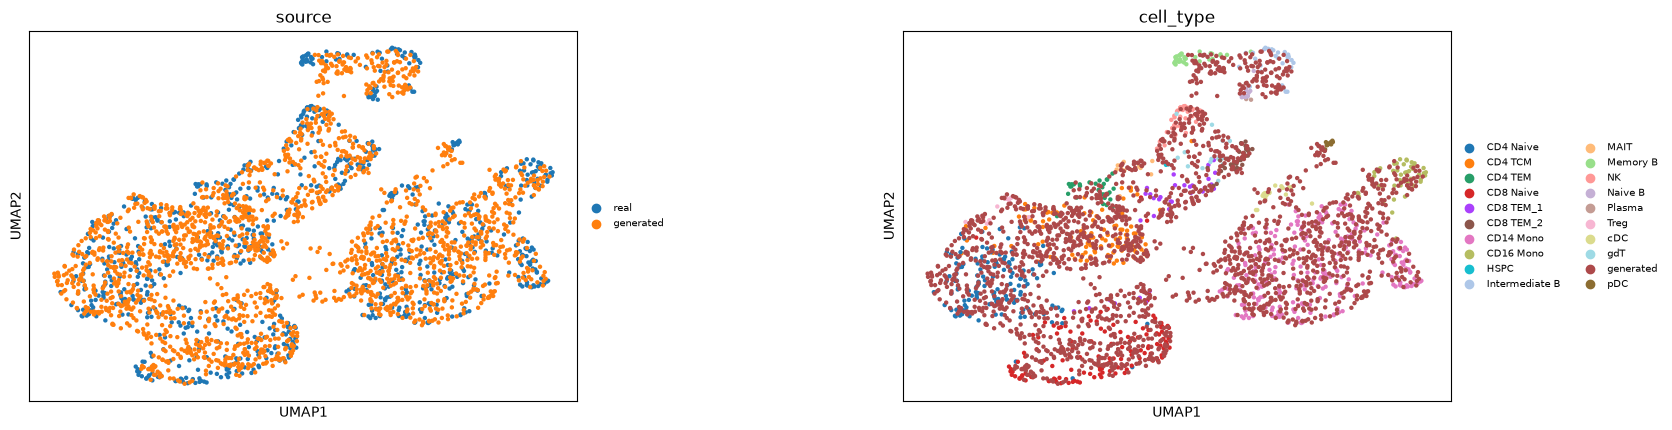

In [8]:
import anndata as ad

genes = pd.DataFrame(index=rna_test.var_names)
real = ad.AnnData(dense(rna_test.X), obs=rna_test.obs[["cell_type"]].copy(), var=genes)
fake = ad.AnnData(generated["rna"].astype(np.float32), var=genes)
fake.obs_names = [f"generated-{i}" for i in range(fake.n_obs)]
fake.obs["cell_type"] = "generated"
both = ad.concat({"real": real, "generated": fake}, label="source")
both.obsm["X_univi"] = encode_adata(model, both, modality="rna", device=device, latent="modality_mean")
sc.pp.neighbors(both, use_rep="X_univi")
sc.tl.umap(both, random_state=0)
sc.pl.umap(both, color=["source", "cell_type"], wspace=0.45, legend_fontsize=7)

### For a chosen cell type

To generate a specific population, fit a Gaussian to each cell type's latent embeddings and sample from it.

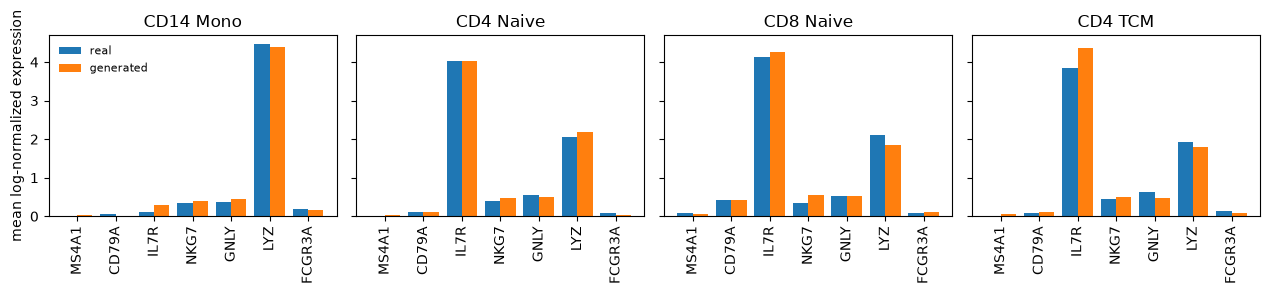

In [9]:
z_train = encode_adata(model, train["rna"], modality="rna", device=device, latent="modality_mean")
gauss = fit_label_latent_gaussians(z_train, train["rna"].obs["cell_type"].astype(str).to_numpy())
counts = train["rna"].obs["cell_type"].value_counts()
chosen = [c for c in counts.index if c in gauss][:4]

rows = {}
for cell_type in chosen:
    z = sample_latent_by_label(gauss, label=cell_type, n=500, random_state=0)
    fake = generate_from_latent(model, z=z, target_mod="rna", device=device)
    real = dense(rna_test[rna_test.obs["cell_type"] == cell_type].X)
    rows[cell_type] = {"generated": pd.Series(fake.mean(0), index=rna_test.var_names)[markers],
                       "real": pd.Series(real.mean(0), index=rna_test.var_names)[markers]}

fig, axes = plt.subplots(1, len(chosen), figsize=(3.2 * len(chosen), 3), sharey=True)
for ax, (cell_type, r) in zip(np.atleast_1d(axes), rows.items()):
    ax.bar(np.arange(len(markers)) - 0.2, r["real"], 0.4, label="real")
    ax.bar(np.arange(len(markers)) + 0.2, r["generated"], 0.4, label="generated")
    ax.set_xticks(range(len(markers)), markers, rotation=90)
    ax.set_title(cell_type)
np.atleast_1d(axes)[0].set_ylabel("mean log-normalized expression")
np.atleast_1d(axes)[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## In-silico perturbation

`predict_feature_perturbation` edits one or more input features (set to zero, set to a value, add, or scale), runs the edited and original inputs through the model, and returns the change in the decoded output. Here we switch off a marker gene in the RNA input of the cells that express it most and ask which decoded genes move with it.

This measures what the **model** has learned to associate with the gene. It is a hypothesis generator, not evidence of causal regulation.

In [10]:
gene = markers[0]
by_type = pd.Series(dense(rna_test[:, gene].X).ravel(), index=rna_test.obs_names).groupby(
    rna_test.obs["cell_type"].astype(str)).mean()
target_type = by_type.idxmax()
cells = rna_test[rna_test.obs["cell_type"] == target_type].copy()

result = predict_feature_perturbation(model, cells, source_modality="rna", target_modality="rna",
                                      features=[gene], mode="off", device=device)
effect = pd.Series(result["delta"].mean(0), index=cells.var_names).drop(gene)
print(f"switched off {gene} in {cells.n_obs} {target_type} cells")
pd.concat({"largest decrease": effect.nsmallest(8), "largest increase": effect.nlargest(8)}).round(4)

switched off MS4A1 in 30 Intermediate B cells


                  genes     
largest decrease  TBC1D9       -0.0177
                  AL355076.2   -0.0174
                  ANK3         -0.0172
                  SNED1        -0.0149
                  AIM2         -0.0149
                  OSBPL10      -0.0142
                  COL4A3       -0.0126
                  CSGALNACT1   -0.0115
largest increase  IGHD          0.0232
                  TCL1A         0.0218
                  IGHM          0.0191
                  CAMK2D        0.0180
                  BACH2         0.0163
                  PCDH9         0.0151
                  COL19A1       0.0145
                  MARCH3        0.0132
dtype: float32